<a href="https://colab.research.google.com/github/vidya100804/AI-ML/blob/main/flight-delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:


import datetime, warnings, scipy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [14]:
flightsinfo = pd.read_csv('/content/flights.csv')
airport = pd.read_csv('/content/airports.csv')
airlines = pd.read_csv('/content/airlines.csv')
print("Flights shape:", flightsinfo.shape)
print("Airports shape:", airport.shape)
print("Airlines shape:", airlines.shape)

Flights shape: (372468, 31)
Airports shape: (322, 7)
Airlines shape: (14, 2)


In [15]:
print(list(flightsinfo.columns))
flightsinfo.info()

['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372468 entries, 0 to 372467
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 372468 non-null  int64  
 1   MONTH                372468 non-null  int64  
 2   DAY                  372467 non-null  float64
 3   DAY_OF_WEEK          372467 non-null  float64
 4   AIRLINE              372467 non-null  object 
 5   FLIGHT_NUMBER        372467 non-null  

In [16]:
print(list(flightsinfo.columns))
flightsinfo.info()

['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372468 entries, 0 to 372467
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 372468 non-null  int64  
 1   MONTH                372468 non-null  int64  
 2   DAY                  372467 non-null  float64
 3   DAY_OF_WEEK          372467 non-null  float64
 4   AIRLINE              372467 non-null  object 
 5   FLIGHT_NUMBER        372467 non-null  

In [17]:
flightsinfo.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,372468.0,372468.0,372467.000000,372467.000000,372467.000000,372467.000000,366381.000000,366381.000000,366196.000000,366196.000000,...,372467.000000,365893.000000,365326.000000,372467.000000,372467.000000,83056.000000,83056.000000,83056.000000,83056.000000,83056.000000
mean,2015.0,1.0,12.627591,4.120846,2266.150996,1317.455691,1328.454999,11.084650,16.548165,1352.085798,...,1500.944137,1487.544853,7.451558,0.002100,0.017073,13.335665,0.069206,17.843383,23.437825,2.828465
std,0.0,0.0,7.079210,1.944178,1805.323339,467.642881,480.406893,38.253807,9.611633,480.411946,...,482.839076,504.566836,41.033027,0.045772,0.129542,25.142239,1.962873,45.318753,41.557454,19.034718
min,2015.0,1.0,1.000000,1.000000,1.000000,5.000000,1.000000,-47.000000,1.000000,1.000000,...,1.000000,1.000000,-82.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,1.0,6.000000,2.000000,761.000000,920.000000,928.000000,-5.000000,11.000000,943.000000,...,1121.000000,1114.000000,-12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,1.0,13.000000,4.000000,1733.000000,1313.000000,1323.000000,-1.000000,14.000000,1337.000000,...,1519.000000,1516.000000,-3.000000,0.000000,0.000000,4.000000,0.000000,2.000000,5.000000,0.000000
75%,2015.0,1.0,19.000000,6.000000,3484.000000,1715.000000,1726.000000,11.000000,19.000000,1740.000000,...,1910.000000,1911.000000,12.000000,0.000000,0.000000,18.000000,0.000000,19.000000,30.000000,0.000000
max,2015.0,1.0,25.000000,7.000000,9793.000000,2359.000000,2400.000000,1988.000000,176.000000,2400.000000,...,2359.000000,2400.000000,1971.000000,1.000000,1.000000,830.000000,237.000000,1971.000000,938.000000,938.000000


In [18]:
flightsinfo.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1.0,4.0,AS,98.0,N407AS,ANC,SEA,5.0,...,408.0,-22.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1.0,4.0,AA,2336.0,N3KUAA,LAX,PBI,10.0,...,741.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1.0,4.0,US,840.0,N171US,SFO,CLT,20.0,...,811.0,5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1.0,4.0,AA,258.0,N3HYAA,LAX,MIA,20.0,...,756.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1.0,4.0,AS,135.0,N527AS,SEA,ANC,25.0,...,259.0,-21.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
airlinecompanies = airlines.set_index('IATA_CODE')['AIRLINE'].to_dict()
print(airlinecompanies)

{'UA': 'United Air Lines Inc.', 'AA': 'American Airlines Inc.', 'US': 'US Airways Inc.', 'F9': 'Frontier Airlines Inc.', 'B6': 'JetBlue Airways', 'OO': 'Skywest Airlines Inc.', 'AS': 'Alaska Airlines Inc.', 'NK': 'Spirit Air Lines', 'WN': 'Southwest Airlines Co.', 'DL': 'Delta Air Lines Inc.', 'EV': 'Atlantic Southeast Airlines', 'HA': 'Hawaiian Airlines Inc.', 'MQ': 'American Eagle Airlines Inc.', 'VX': 'Virgin America'}


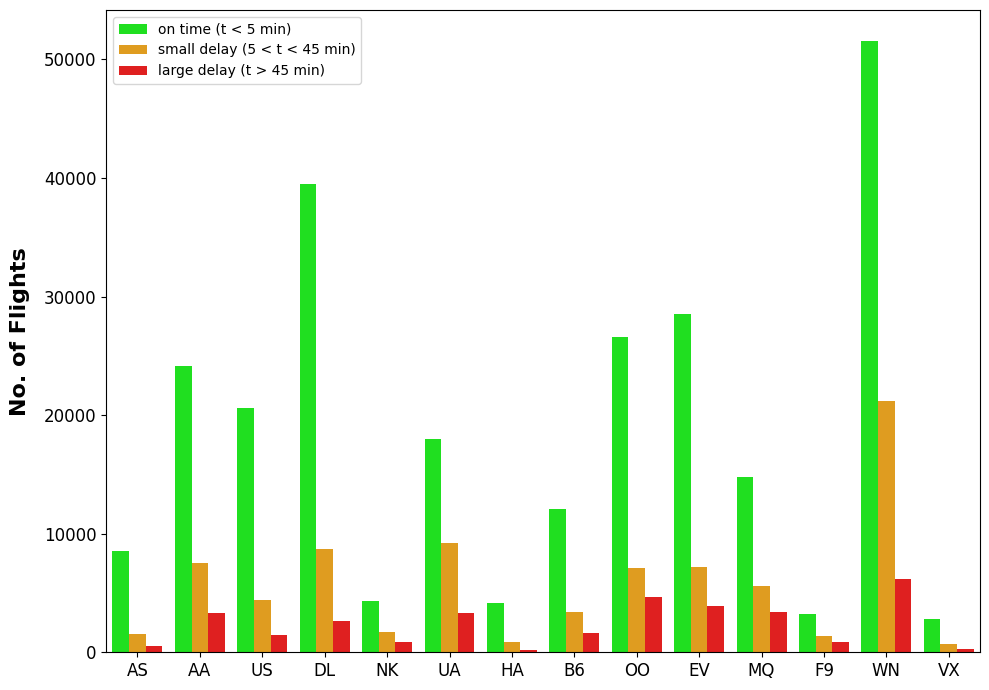

In [20]:
delay_type = lambda x: ((0, 1)[x > 5], 2)[x > 45]
flightsinfo['DELAY_LEVEL'] = flightsinfo['DEPARTURE_DELAY'].apply(delay_type)

fig = plt.figure(1, figsize=(10, 7))
ax = sns.countplot(x="AIRLINE", hue='DELAY_LEVEL', data=flightsinfo,
                   palette=["#00FF00", "#FFA500", "#FF0000"])
ax.set_xticklabels(ax.get_xticklabels())
plt.setp(ax.get_yticklabels(), fontsize=12)
plt.setp(ax.get_xticklabels(), fontsize=12, rotation=0)
ax.xaxis.label.set_visible(False)
plt.ylabel('No. of Flights', fontsize=16, weight='bold', labelpad=10)

L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.tight_layout()
plt.show()

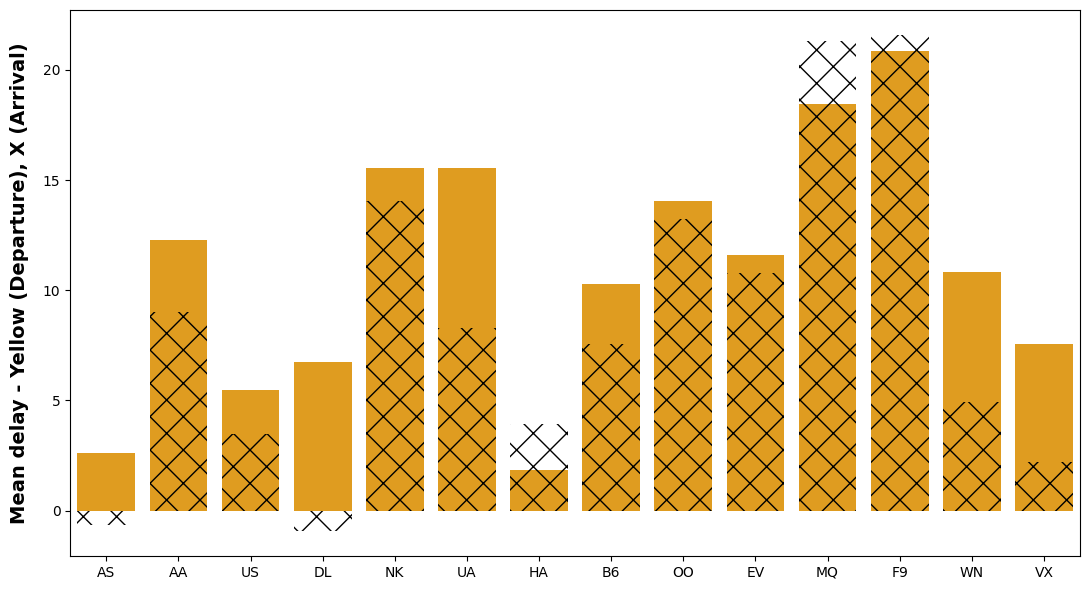

In [47]:
fig = plt.figure(1, figsize=(11, 6))
ax = sns.barplot(x="AIRLINE", y="DEPARTURE_DELAY", data=flightsinfo,
                 color="orange", ci=None)
ax = sns.barplot(x="AIRLINE", y="ARRIVAL_DELAY", data=flightsinfo,
                 color="b", hatch='X', alpha=0.0, ci=None)
ax.xaxis.label.set_visible(False)
plt.ylabel('Mean delay - Yellow (Departure), X (Arrival)',
           fontsize=14, weight='bold', labelpad=10)
plt.tight_layout()
plt.show()

In [54]:
!apt-get install -y libgeos-3.5.0 libgeos-dev
!pip install https://github.com/matplotlib/basemap/archive/master.zip

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package libgeos-3.5.0
E: Couldn't find any package by glob 'libgeos-3.5.0'
E: Couldn't find any package by regex 'libgeos-3.5.0'
     / 129.7 MB 10.6 MB/s 0:00:12
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


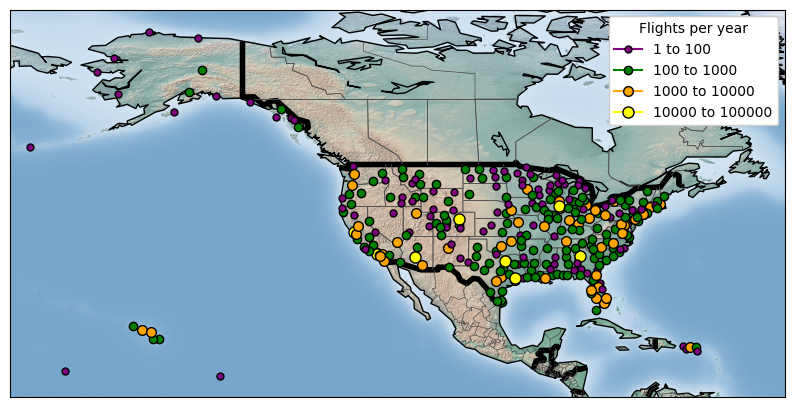

In [55]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from collections import OrderedDict

flightcount = flightsinfo['ORIGIN_AIRPORT'].value_counts()

plt.figure(figsize=(10, 10))

colors = ['purple', 'green', 'orange', 'yellow', 'red', 'lightblue']
size   = [1, 100, 1000, 10000, 100000, 1000000]
labels = ["1 to 100", "100 to 1000", "1000 to 10000",
          "10000 to 100000", "100000 to 1000000"]

map = Basemap(llcrnrlon=-180, urcrnrlon=-50,
              llcrnrlat=10,  urcrnrlat=75,
              lat_0=0, lon_0=0)
map.shadedrelief()
map.drawcoastlines()
map.drawcountries(linewidth=4)
map.drawstates(color='0.3')

for index, (code, y, x) in airport[['IATA_CODE', 'LATITUDE', 'LONGITUDE']].iterrows():
    # skip airports not in flightcount
    if code not in flightcount:
        continue
    x, y = map(x, y)
    isize = [i for i, val in enumerate(size) if val < flightcount[code]]
    if not isize:
        continue
    ind = isize[-1]
    map.plot(x, y, marker='o',
             markersize=ind + 5,
             markeredgewidth=1,
             color=colors[ind],
             markeredgecolor='k',
             label=labels[ind])

handles, labels = plt.gca().get_legend_handles_labels()
labels_ord = OrderedDict(zip(labels, handles))
keys = ('1 to 100', '100 to 1000', '1000 to 10000',
        '10000 to 100000', '100000 to 1000000')
lnew = OrderedDict()
for item in keys:
    if item in labels_ord:
        lnew[item] = labels_ord[item]

plt.legend(lnew.values(), lnew.keys(),
           loc=1, prop={'size': 10},
           title='Flights per year',
           frameon=True, framealpha=1)
plt.show()

In [22]:
print(airport.isnull().sum())
airport = airport.dropna(subset=['LATITUDE', 'LONGITUDE'])
airport.head(10)

IATA_CODE    0
AIRPORT      0
CITY         0
STATE        0
COUNTRY      0
LATITUDE     3
LONGITUDE    3
dtype: int64


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
5,ACK,Nantucket Memorial Airport,Nantucket,MA,USA,41.25305,-70.06018
6,ACT,Waco Regional Airport,Waco,TX,USA,31.61129,-97.23052
7,ACV,Arcata Airport,Arcata/Eureka,CA,USA,40.97812,-124.10862
8,ACY,Atlantic City International Airport,Atlantic City,NJ,USA,39.45758,-74.57717
9,ADK,Adak Airport,Adak,AK,USA,51.87796,-176.64603


In [23]:
flightsinfo_NULL = flightsinfo.isnull().sum() * 100 / flightsinfo.shape[0]
print(flightsinfo_NULL)

YEAR                    0.000000
MONTH                   0.000000
DAY                     0.000268
DAY_OF_WEEK             0.000268
AIRLINE                 0.000268
FLIGHT_NUMBER           0.000268
TAIL_NUMBER             0.159208
ORIGIN_AIRPORT          0.000268
DESTINATION_AIRPORT     0.000268
SCHEDULED_DEPARTURE     0.000268
DEPARTURE_TIME          1.634234
DEPARTURE_DELAY         1.634234
TAXI_OUT                1.683903
WHEELS_OFF              1.683903
SCHEDULED_TIME          0.000268
ELAPSED_TIME            1.917480
AIR_TIME                1.917480
DISTANCE                0.000268
WHEELS_ON               1.765252
TAXI_IN                 1.765252
SCHEDULED_ARRIVAL       0.000268
ARRIVAL_TIME            1.765252
ARRIVAL_DELAY           1.917480
DIVERTED                0.000268
CANCELLED               0.000268
CANCELLATION_REASON    98.292739
AIR_SYSTEM_DELAY       77.701172
SECURITY_DELAY         77.701172
AIRLINE_DELAY          77.701172
LATE_AIRCRAFT_DELAY    77.701172
WEATHER_DE

In [24]:
flightsinfo1 = flightsinfo.dropna(subset=[
    "TAIL_NUMBER", 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
    'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME',
    'ELAPSED_TIME', 'AIR_TIME', 'WHEELS_ON',
    'TAXI_IN', 'ARRIVAL_TIME', 'ARRIVAL_DELAY'
])
print("Shape after drop:", flightsinfo1.shape)
flightsinfo1.isnull().sum()

Shape after drop: (365326, 32)


,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,0
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [25]:
flightsinfo_modified = flightsinfo1.dropna(subset=[
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
])
flightsinfo_modified = flightsinfo_modified.drop([
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'TAIL_NUMBER',
    'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'SCHEDULED_TIME',
    'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'DIVERTED', 'CANCELLED',
    'CANCELLATION_REASON', 'FLIGHT_NUMBER', 'WHEELS_OFF',
    'WHEELS_ON', 'AIR_TIME'
], axis=1)

Flight_Delays = flightsinfo_modified
print(Flight_Delays.shape)
Flight_Delays.info()

(83056, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 83056 entries, 27 to 372458
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AIRLINE              83056 non-null  object 
 1   ORIGIN_AIRPORT       83056 non-null  object 
 2   DESTINATION_AIRPORT  83056 non-null  object 
 3   DEPARTURE_DELAY      83056 non-null  float64
 4   TAXI_OUT             83056 non-null  float64
 5   ELAPSED_TIME         83056 non-null  float64
 6   DISTANCE             83056 non-null  float64
 7   TAXI_IN              83056 non-null  float64
 8   ARRIVAL_DELAY        83056 non-null  float64
 9   AIR_SYSTEM_DELAY     83056 non-null  float64
 10  SECURITY_DELAY       83056 non-null  float64
 11  AIRLINE_DELAY        83056 non-null  float64
 12  LATE_AIRCRAFT_DELAY  83056 non-null  float64
 13  WEATHER_DELAY        83056 non-null  float64
 14  DELAY_LEVEL          83056 non-null  int64  
dtypes: float64(11), int64(1), o

In [27]:
def CreateTimeFormatted(hours):
    if hours == 2400:
        hours = 0
    else:
        hours = "{0:04d}".format(int(hours))
        Hourmin = datetime.time(int(hours[0:2]), int(hours[2:4]))
        return Hourmin

flightsinfo2 = flightsinfo1.copy()
flightsinfo2['Actual_Departure'] = flightsinfo1['DEPARTURE_TIME'].apply(CreateTimeFormatted)
print(flightsinfo2['Actual_Departure'].head())

0    23:54:00
1    00:02:00
2    00:18:00
3    00:15:00
4    00:24:00
Name: Actual_Departure, dtype: object


In [28]:
flightsinfo2['Date'] = pd.to_datetime(flightsinfo2[['YEAR', 'MONTH', 'DAY']])
flightsinfo2['Day'] = flightsinfo2['Date'].dt.day_name()

flightsinfo2['Scheduled_Arrival']   = flightsinfo1['SCHEDULED_ARRIVAL'].apply(CreateTimeFormatted)
flightsinfo2['Scheduled_Departure'] = flightsinfo1['SCHEDULED_DEPARTURE'].apply(CreateTimeFormatted)
flightsinfo2['Actual_Arrival']      = flightsinfo2['ARRIVAL_TIME'].apply(CreateTimeFormatted)

In [29]:
flightsinfo2 = flightsinfo2.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='inner')
flightsinfo2 = flightsinfo2.drop(['AIRLINE_x', 'IATA_CODE'], axis=1)
flightsinfo2 = flightsinfo2.rename(columns={"AIRLINE_y": "AIRLINE"})

flightsinfo2 = flightsinfo2.merge(airport, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='inner')
flightsinfo2 = flightsinfo2.merge(airport, left_on='DESTINATION_AIRPORT', right_on='IATA_CODE', how='inner')

print(flightsinfo2.columns.tolist())

['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DELAY_LEVEL', 'Actual_Departure', 'Date', 'Day', 'Scheduled_Arrival', 'Scheduled_Departure', 'Actual_Arrival', 'AIRLINE', 'IATA_CODE_x', 'AIRPORT_x', 'CITY_x', 'STATE_x', 'COUNTRY_x', 'LATITUDE_x', 'LONGITUDE_x', 'IATA_CODE_y', 'AIRPORT_y', 'CITY_y', 'STATE_y', 'COUNTRY_y', 'LATITUDE_y', 'LONGITUDE_y']


In [30]:
flightsinfo2 = flightsinfo2.drop([
    'LATITUDE_x', 'LONGITUDE_x', 'STATE_y', 'COUNTRY_y',
    'LATITUDE_y', 'LONGITUDE_y', 'STATE_x', 'COUNTRY_x'
], axis=1)

flightsinfo2 = flightsinfo2.rename(columns={
    'IATA_CODE_x': 'Org_Airport_Code',
    'AIRPORT_x':   'Org_Airport_Name',
    'CITY_x':      'Origin_city',
    'IATA_CODE_y': 'Dest_Airport_Code',
    'AIRPORT_y':   'Dest_Airport_Name',
    'CITY_y':      'Destination_city'
})

print(flightsinfo2.shape)
flightsinfo2.head()

(364885, 44)


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,...,Scheduled_Arrival,Scheduled_Departure,Actual_Arrival,AIRLINE,Org_Airport_Code,Org_Airport_Name,Origin_city,Dest_Airport_Code,Dest_Airport_Name,Destination_city
0,2015,1,1.0,4.0,98.0,N407AS,ANC,SEA,5.0,2354.0,...,04:30:00,00:05:00,04:08:00,Alaska Airlines Inc.,ANC,Ted Stevens Anchorage International Airport,Anchorage,SEA,Seattle-Tacoma International Airport,Seattle
1,2015,1,1.0,4.0,2336.0,N3KUAA,LAX,PBI,10.0,2.0,...,07:50:00,00:10:00,07:41:00,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,PBI,Palm Beach International Airport,West Palm Beach
2,2015,1,1.0,4.0,840.0,N171US,SFO,CLT,20.0,18.0,...,08:06:00,00:20:00,08:11:00,US Airways Inc.,SFO,San Francisco International Airport,San Francisco,CLT,Charlotte Douglas International Airport,Charlotte
3,2015,1,1.0,4.0,258.0,N3HYAA,LAX,MIA,20.0,15.0,...,08:05:00,00:20:00,07:56:00,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,MIA,Miami International Airport,Miami
4,2015,1,1.0,4.0,135.0,N527AS,SEA,ANC,25.0,24.0,...,03:20:00,00:25:00,02:59:00,Alaska Airlines Inc.,SEA,Seattle-Tacoma International Airport,Seattle,ANC,Ted Stevens Anchorage International Airport,Anchorage


In [31]:
data_vizual = pd.DataFrame(flightsinfo2[[
    'AIRLINE', 'Org_Airport_Name', 'Origin_city',
    'Dest_Airport_Name', 'Destination_city',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE',
    'Actual_Departure', 'Date', 'Day', 'Scheduled_Departure',
    'DEPARTURE_DELAY', 'Actual_Arrival', 'Scheduled_Arrival',
    'ARRIVAL_DELAY', 'SCHEDULED_TIME', 'ELAPSED_TIME',
    'AIR_TIME', 'TAXI_IN', 'TAXI_OUT', 'DIVERTED'
]])

data_vizual = data_vizual.dropna(subset=['Actual_Departure', 'Actual_Arrival'])
Flights = data_vizual
print(Flights.shape)
Flights.info()

(364726, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 364726 entries, 0 to 364884
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   AIRLINE              364726 non-null  object        
 1   Org_Airport_Name     364726 non-null  object        
 2   Origin_city          364726 non-null  object        
 3   Dest_Airport_Name    364726 non-null  object        
 4   Destination_city     364726 non-null  object        
 5   ORIGIN_AIRPORT       364726 non-null  object        
 6   DESTINATION_AIRPORT  364726 non-null  object        
 7   DISTANCE             364726 non-null  float64       
 8   Actual_Departure     364726 non-null  object        
 9   Date                 364726 non-null  datetime64[ns]
 10  Day                  364726 non-null  object        
 11  Scheduled_Departure  364726 non-null  object        
 12  DEPARTURE_DELAY      364726 non-null  float64       
 13  Actual

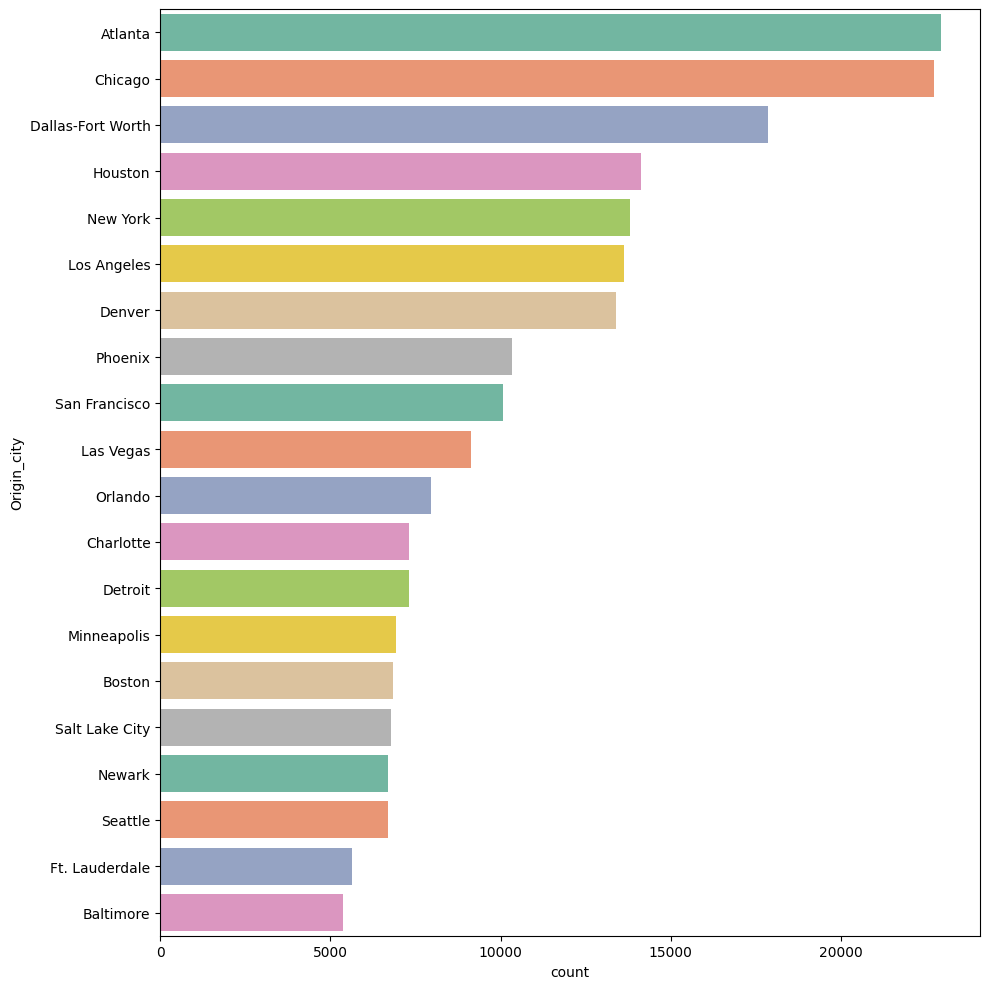

In [32]:
plt.figure(figsize=(10, 10))
axis = sns.countplot(
    y=Flights['Origin_city'], data=Flights,
    order=Flights['Origin_city'].value_counts().iloc[:20].index,
    palette="Set2"
)
plt.tight_layout()
plt.show()

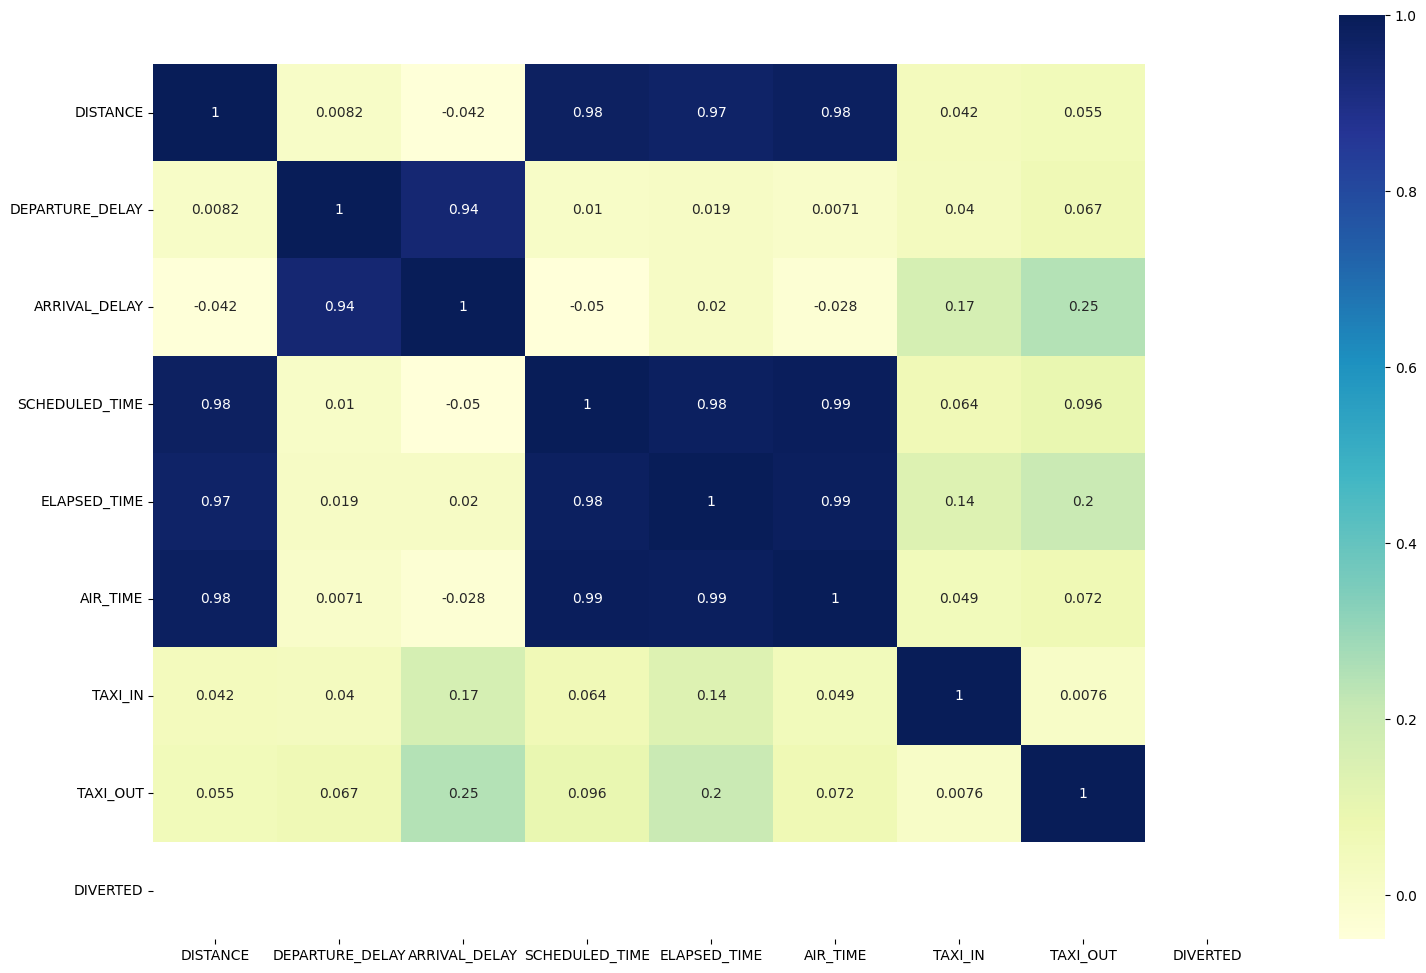

In [34]:
fig, axis = plt.subplots(figsize=(18, 12))
sns.heatmap(Flights.select_dtypes(include=np.number).corr(), annot=True, cmap="YlGnBu")
b, t = plt.ylim()
plt.ylim(b, t - 0.5)
plt.show()

In [35]:
Flights1 = Flights.drop([
    'Org_Airport_Name', 'Origin_city',
    'Dest_Airport_Name', 'Destination_city'
], axis=1)

print(Flights1.columns.tolist())

['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE', 'Actual_Departure', 'Date', 'Day', 'Scheduled_Departure', 'DEPARTURE_DELAY', 'Actual_Arrival', 'Scheduled_Arrival', 'ARRIVAL_DELAY', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'TAXI_IN', 'TAXI_OUT', 'DIVERTED']


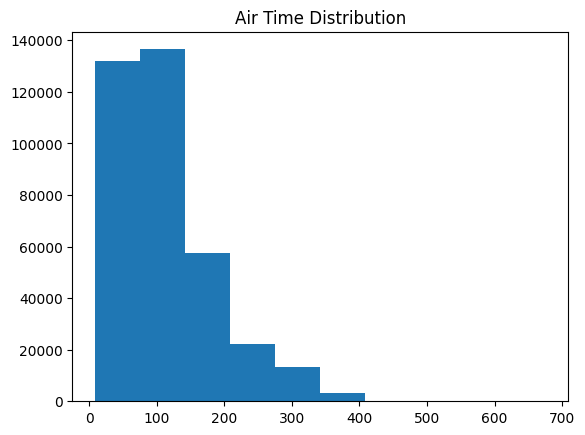

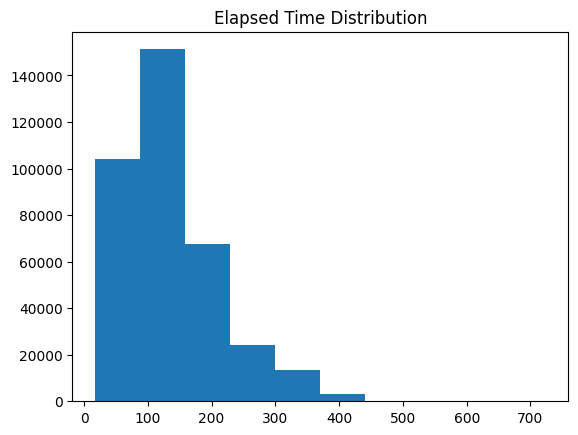

In [36]:
plt.hist(Flights1['AIR_TIME'])
plt.title("Air Time Distribution")
plt.show()

plt.hist(Flights1['ELAPSED_TIME'])
plt.title("Elapsed Time Distribution")
plt.show()

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

Flights1['AIRLINE']             = le.fit_transform(Flights1['AIRLINE'])
Flights1['ORIGIN_AIRPORT']      = le.fit_transform(Flights1['ORIGIN_AIRPORT'])
Flights1['DESTINATION_AIRPORT'] = le.fit_transform(Flights1['DESTINATION_AIRPORT'])
Flights1['Day']                 = le.fit_transform(Flights1['Day'])

Flights1 = Flights1.drop([
    'Scheduled_Departure', 'Scheduled_Arrival',
    'Actual_Arrival', 'Date', 'Actual_Departure'
], axis=1)

Flights1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364726 entries, 0 to 364884
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   AIRLINE              364726 non-null  int64  
 1   ORIGIN_AIRPORT       364726 non-null  int64  
 2   DESTINATION_AIRPORT  364726 non-null  int64  
 3   DISTANCE             364726 non-null  float64
 4   Day                  364726 non-null  int64  
 5   DEPARTURE_DELAY      364726 non-null  float64
 6   ARRIVAL_DELAY        364726 non-null  float64
 7   SCHEDULED_TIME       364726 non-null  float64
 8   ELAPSED_TIME         364726 non-null  float64
 9   AIR_TIME             364726 non-null  float64
 10  TAXI_IN              364726 non-null  float64
 11  TAXI_OUT             364726 non-null  float64
 12  DIVERTED             364726 non-null  float64
dtypes: float64(9), int64(4)
memory usage: 39.0 MB


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = Flights1.drop('ARRIVAL_DELAY', axis=1)
y = Flights1['ARRIVAL_DELAY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=5)

sc1 = StandardScaler()
X_train_sc = sc1.fit_transform(X_train)
X_test_sc  = sc1.transform(X_test)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (273544, 12) | X_test: (91182, 12)


MAE: 3.968668764266147e-14
MSE: 2.921398153671039e-27
RMSE: 5.4049959793426663e-14
R2: 1.0


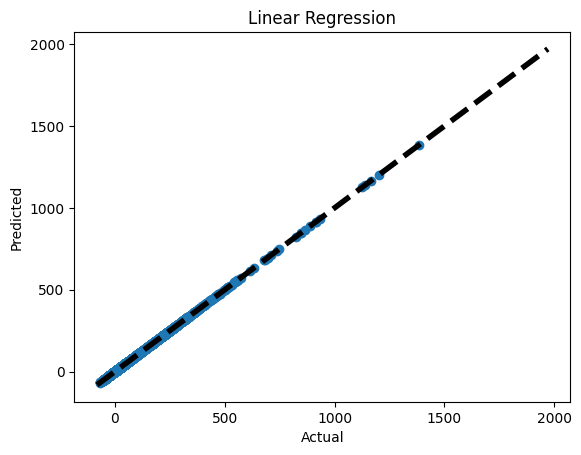

In [39]:
from sklearn.linear_model import LinearRegression

LinR = LinearRegression()
LinR.fit(X_train_sc, y_train)
y_pred = LinR.predict(X_test_sc)

print('MAE:',  mean_absolute_error(y_test, y_pred))
print('MSE:',  mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:',   r2_score(y_test, y_pred))

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Linear Regression')
plt.show()

MAE: 1.7679962053914149
MSE: 15.473707748239784
RMSE: 3.9336634004754125
R2: 0.9909196994008979


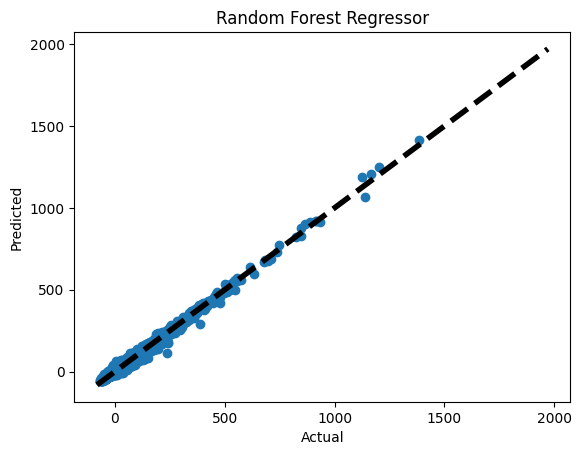

In [40]:
from sklearn.ensemble import RandomForestRegressor

Rfc = RandomForestRegressor(random_state=2)
Rfc.fit(X_train_sc, y_train)
y_pred_rf = Rfc.predict(X_test_sc)

print('MAE:',  mean_absolute_error(y_test, y_pred_rf))
print('MSE:',  mean_squared_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('R2:',   r2_score(y_test, y_pred_rf))

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred_rf)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Random Forest Regressor')
plt.show()

MAE: 3.0482003026913205
MSE: 34.66400166699568
RMSE: 5.887614259358003
R2: 0.9796584270411915


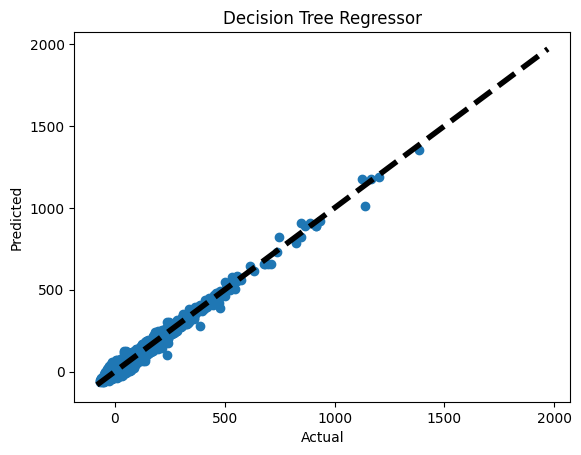

In [41]:
from sklearn.tree import DecisionTreeRegressor

Dtc = DecisionTreeRegressor(random_state=2)
Dtc.fit(X_train_sc, y_train)
y_pred_dt = Dtc.predict(X_test_sc)

print('MAE:',  mean_absolute_error(y_test, y_pred_dt))
print('MSE:',  mean_squared_error(y_test, y_pred_dt))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print('R2:',   r2_score(y_test, y_pred_dt))

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred_dt)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Decision Tree Regressor')
plt.show()

MAE: 9.855852397947104e-14
MSE: 1.240004548808815e-26
RMSE: 1.1135549150395839e-13
R2: 1.0


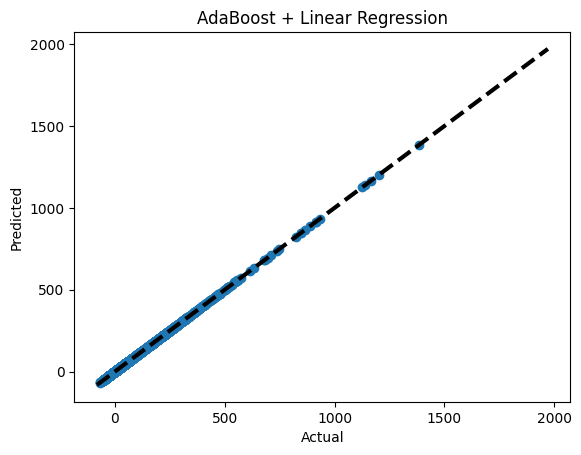

In [43]:
from sklearn.ensemble import AdaBoostRegressor

Boost_Lin = AdaBoostRegressor(estimator=LinR, random_state=2)
Boost_Lin.fit(X_train_sc, y_train)
y_pred_bl = Boost_Lin.predict(X_test_sc)

print('MAE:',  mean_absolute_error(y_test, y_pred_bl))
print('MSE:',  mean_squared_error(y_test, y_pred_bl))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_bl)))
print('R2:',   r2_score(y_test, y_pred_bl))

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred_bl)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=3)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('AdaBoost + Linear Regression')
plt.show()

MAE: 20.00901938552887
MSE: 1448.353912038089
RMSE: 38.05724519770301
R2: 0.014682235027313806


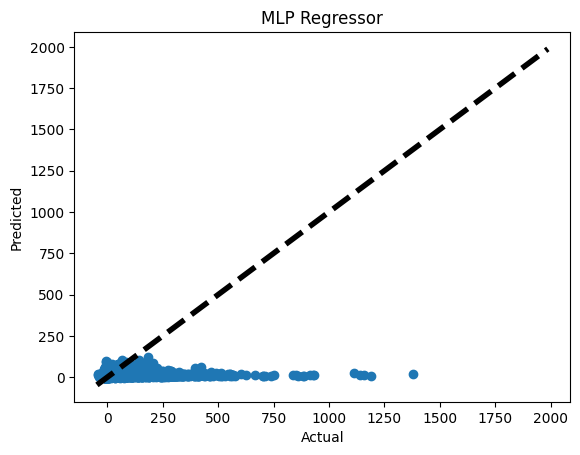

In [44]:
from sklearn.neural_network import MLPRegressor

X2 = Flights1.drop(['ARRIVAL_DELAY', 'DEPARTURE_DELAY'], axis=1)
y2 = Flights1['DEPARTURE_DELAY']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.25, random_state=5)

sc2 = StandardScaler()
X_train2_sc = sc2.fit_transform(X_train2)
X_test2_sc  = sc2.transform(X_test2)

mlp = MLPRegressor(random_state=0, activation='relu', hidden_layer_sizes=16)
mlp.fit(X_train2_sc, y_train2)
y_pred_mlp = mlp.predict(X_test2_sc)

print('MAE:',  mean_absolute_error(y_test2, y_pred_mlp))
print('MSE:',  mean_squared_error(y_test2, y_pred_mlp))
print('RMSE:', np.sqrt(mean_squared_error(y_test2, y_pred_mlp)))
print('R2:',   r2_score(y_test2, y_pred_mlp))

fig, ax = plt.subplots()
ax.scatter(y_test2, y_pred_mlp)
ax.plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'k--', lw=4)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('MLP Regressor')
plt.show()

In [48]:
Flights1['Is_Delayed'] = np.where(Flights1['ARRIVAL_DELAY'] <= 0, 0, 1)
print(Flights1['Is_Delayed'].value_counts())
Flights1.head()

Is_Delayed
0    210689
1    154037
Name: count, dtype: int64


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,Day,DEPARTURE_DELAY,ARRIVAL_DELAY,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,TAXI_IN,TAXI_OUT,DIVERTED,Is_Delayed
0,0,15,266,1448.0,4,-11.0,-22.0,205.0,194.0,169.0,4.0,21.0,0.0,0
1,1,167,224,2330.0,4,-8.0,-9.0,280.0,279.0,263.0,4.0,12.0,0.0,0
2,11,267,62,2296.0,4,-2.0,5.0,286.0,293.0,266.0,11.0,16.0,0.0,1
3,1,167,194,2342.0,4,-5.0,-9.0,285.0,281.0,258.0,8.0,15.0,0.0,0
4,0,266,15,1448.0,4,-1.0,-21.0,235.0,215.0,199.0,5.0,11.0,0.0,0


In [49]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix)

X_cls = Flights1.drop(['ARRIVAL_DELAY', 'Is_Delayed'], axis=1)
y_cls = Flights1['Is_Delayed']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=2
)

print("Before SMOTE:", pd.Series(y_train_c).value_counts().to_dict())

smt = SMOTE()
X_train_c, y_train_c = smt.fit_resample(X_train_c, y_train_c)

print("After SMOTE:", pd.Series(y_train_c).value_counts().to_dict())

sc3 = StandardScaler()
X_train_c_sc = sc3.fit_transform(X_train_c)
X_test_c_sc  = sc3.transform(X_test_c)

Before SMOTE: {0: 147712, 1: 107596}
After SMOTE: {0: 147712, 1: 147712}


Accuracy: 0.944396717176333
F1 Score: 0.9430938734798877
Precision: 0.9431189908850187
Recall: 0.9430688234097482


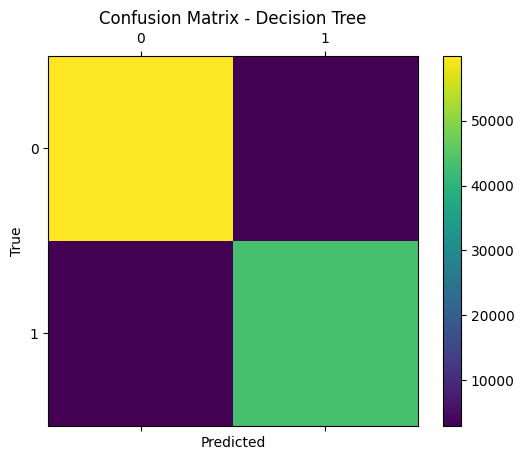

In [50]:
from sklearn.tree import DecisionTreeClassifier

classifierDT = DecisionTreeClassifier(criterion='entropy', random_state=42)
classifierDT.fit(X_train_c_sc, y_train_c)

y_pred_dtc = classifierDT.predict(X_test_c_sc)
cm = confusion_matrix(y_test_c, y_pred_dtc)

print("Accuracy:", classifierDT.score(X_test_c_sc, y_test_c))
print("F1 Score:", f1_score(y_test_c, y_pred_dtc, average="macro"))
print("Precision:", precision_score(y_test_c, y_pred_dtc, average="macro"))
print("Recall:", recall_score(y_test_c, y_pred_dtc, average="macro"))

fig, ax = plt.subplots()
cax = ax.matshow(cm)
plt.title('Confusion Matrix - Decision Tree')
fig.colorbar(cax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Accuracy: 0.8424939223893692
F1 Score: 0.834016468420584
Precision: 0.851584842905618
Recall: 0.8272333524101902


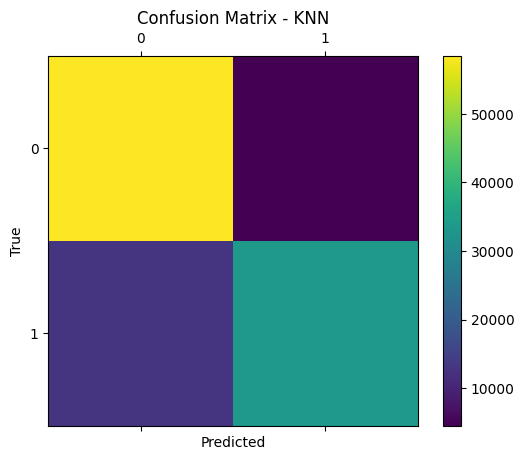

In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
knn.fit(X_train_c_sc, y_train_c)

y_pred_knn = knn.predict(X_test_c_sc)
cm_knn = confusion_matrix(y_test_c, y_pred_knn)

print("Accuracy:", knn.score(X_test_c_sc, y_test_c))
print("F1 Score:", f1_score(y_test_c, y_pred_knn, average="macro"))
print("Precision:", precision_score(y_test_c, y_pred_knn, average="macro"))
print("Recall:", recall_score(y_test_c, y_pred_knn, average="macro"))

fig, ax = plt.subplots()
cax = ax.matshow(cm_knn)
plt.title('Confusion Matrix - KNN')
fig.colorbar(cax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Accuracy: 0.9999543036794677
F1 Score: 0.9999532362730157
Precision: 0.9999461740515868
Recall: 0.9999603029677502


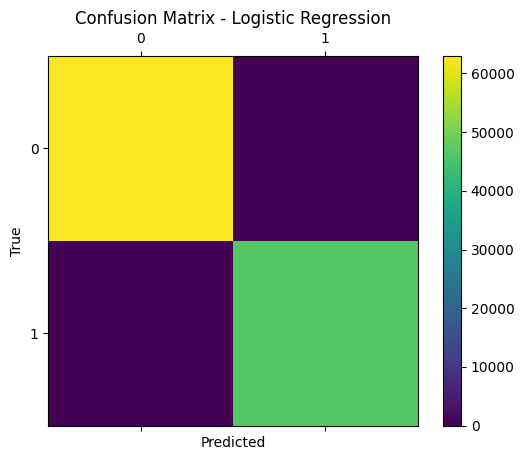

In [52]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(random_state=0, max_iter=200)
lr_clf.fit(X_train_c_sc, y_train_c)

y_pred_lr = lr_clf.predict(X_test_c_sc)
cm_lr = confusion_matrix(y_test_c, y_pred_lr)

print("Accuracy:", lr_clf.score(X_test_c_sc, y_test_c))
print("F1 Score:", f1_score(y_test_c, y_pred_lr, average="macro"))
print("Precision:", precision_score(y_test_c, y_pred_lr, average="macro"))
print("Recall:", recall_score(y_test_c, y_pred_lr, average="macro"))

fig, ax = plt.subplots()
cax = ax.matshow(cm_lr)
plt.title('Confusion Matrix - Logistic Regression')
fig.colorbar(cax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Accuracy: 0.828785026229688
F1 Score: 0.8175589300596051
Precision: 0.8436123098929897
Recall: 0.8097919167509464


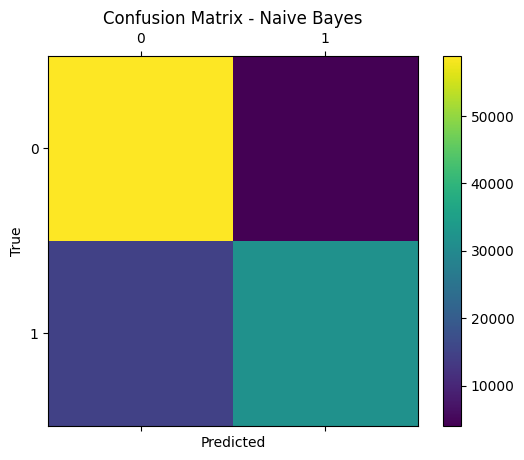

In [53]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_c_sc, y_train_c)

y_pred_gnb = gnb.predict(X_test_c_sc)
cm_gnb = confusion_matrix(y_test_c, y_pred_gnb)

print("Accuracy:", gnb.score(X_test_c_sc, y_test_c))
print("F1 Score:", f1_score(y_test_c, y_pred_gnb, average="macro"))
print("Precision:", precision_score(y_test_c, y_pred_gnb, average="macro"))
print("Recall:", recall_score(y_test_c, y_pred_gnb, average="macro"))

fig, ax = plt.subplots()
cax = ax.matshow(cm_gnb)
plt.title('Confusion Matrix - Naive Bayes')
fig.colorbar(cax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()